In [6]:
import torch
import torchvision
from torchvision import datasets , transforms
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

train_dataset = datasets.ImageFolder(
    root = "/content/brain_tumour/Train",
    transform = transform
)

test_dataset = datasets.ImageFolder(
    root = "/content/brain_tumour/Test",

    transform = transform
)

train_loader = DataLoader(
    dataset = train_dataset,
    batch_size = 64,
    shuffle = True
)

test_loader = DataLoader(
    dataset = test_dataset,
    batch_size = 64,
)

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import zipfile

with zipfile.ZipFile("/content/drive/MyDrive/brain_tumour.zip", "r") as zip_ref:
    zip_ref.extractall("/content/")

print("Extracted!")

Extracted!


In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# load without resize first
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    root="/content/brain_tumour/Train",
    transform=transform
)

# check first image size
image, label = train_dataset[0]
print(f"Image shape: {image.shape}")
print(f"Channels: {image.shape[0]}")   # 1=grayscale, 3=RGB
print(f"Height: {image.shape[1]}")
print(f"Width: {image.shape[2]}")

Image shape: torch.Size([3, 256, 256])
Channels: 3
Height: 256
Width: 256


In [8]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3,64,kernel_size = 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64,128,kernel_size = 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128,256,kernel_size = 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(256*32*32, 512),
            nn.ReLU(),
            nn.Linear(512, 4)
            )
    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x


In [9]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Using: cuda


In [10]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {running_loss/len(train_loader):.4f} | Accuracy: {accuracy:.2f}%")

Epoch 1/10 | Loss: 0.6093 | Accuracy: 76.12%
Epoch 2/10 | Loss: 0.2327 | Accuracy: 91.35%
Epoch 3/10 | Loss: 0.0916 | Accuracy: 96.83%
Epoch 4/10 | Loss: 0.0514 | Accuracy: 98.28%
Epoch 5/10 | Loss: 0.0278 | Accuracy: 99.10%
Epoch 6/10 | Loss: 0.0204 | Accuracy: 99.33%
Epoch 7/10 | Loss: 0.0212 | Accuracy: 99.35%
Epoch 8/10 | Loss: 0.0215 | Accuracy: 99.32%
Epoch 9/10 | Loss: 0.0204 | Accuracy: 99.47%
Epoch 10/10 | Loss: 0.0168 | Accuracy: 99.47%


In [11]:
torch.save(model.state_dict(), "/content/brain_tumor_model.pth")

print("Model Saved!")

Model Saved!


In [12]:
from google.colab import files
files.download("/content/brain_tumor_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# -------------------------
# DEFINE MODEL AGAIN
# -------------------------

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3,64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(64,128,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(128,256,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(256*32*32,512),
            nn.ReLU(),
            nn.Linear(512,4)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x


# -------------------------
# LOAD MODEL
# -------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN().to(device)

model.load_state_dict(
    torch.load("/content/brain_tumor_model.pth", map_location=device)
)

model.eval()

print("Model Loaded Successfully!")


# -------------------------
# CLASS NAMES
# -------------------------

classes = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary"
]


# -------------------------
# IMAGE TRANSFORM
# -------------------------

transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.5,0.5,0.5],
        [0.5,0.5,0.5]
    )
])


# -------------------------
# PREDICTION FUNCTION
# -------------------------

def predict_image(image_path):

    image = Image.open(image_path).convert("RGB")

    input_tensor = transform(image)

    input_tensor = input_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)

        probabilities = torch.softmax(outputs, dim=1)

        confidence, predicted = torch.max(probabilities, 1)

    predicted_class = classes[predicted.item()]
    confidence_score = confidence.item() * 100

    # SHOW IMAGE
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    print(f"Prediction : {predicted_class}")
    print(f"Confidence : {confidence_score:.2f}%")

Model Loaded Successfully!


In [14]:
from google.colab import files

uploaded = files.upload()

Saving brain.jpeg to brain.jpeg


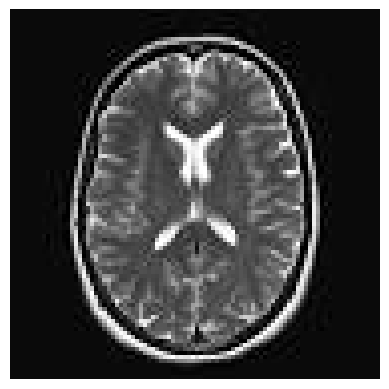

Prediction : no_tumor
Confidence : 100.00%


In [15]:
predict_image("/content/brain.jpeg")

In [16]:
from google.colab import files

uploaded = files.upload()

Saving meno.jpeg to meno.jpeg


In [18]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 95.00%
